## Project Overview

In this project, my goal is to analyze the population of trees in Minneapolis. We will start by loading the data and creating a DataFrame that has a listing of all trees in the city of Minneapolis as published in the dataset being used. This dataset is not inclusive of every tree in Minneapolis, but does contain a  of the tree population maintained by the city, or tracked by certain nonprofit groups.

We'll get started by loading all of the modules we'll need for the project

In [6]:
# Load necessary modules
import os
import pandas as pd
import geopandas as gpd

## Load Files
Here we're loading the necessary files. We're going to load a .geojson file which will contain the geo boundaries for Minneapolis neighborhoods as well as a .csv file with contains all of the tree speciments tracked as part of a 2024 academic study of trees in the Twin Cities.

In [7]:
# Load trees data for Twin Cities Trees
tree_data = pd.read_csv(os.path.join("data", "MSPtrees_2023.csv"))

# Load the GeoJSON file
neighborhoods_geo = gpd.read_file(os.path.join("data", "minneapolis_neighborhoods.geojson"))
print(neighborhoods_geo.crs)

tree_data.head(10)

EPSG:4326


,entity,givn_nm,genus_sp,genus,epithet,city,lat,lon,plot_lvl,lnd_cvr,cvr_code
0,adopt_a_tree,Quercus bicolor,Quercus bicolor,Quercus,bicolor,Minneapolis,44.924594,-93.293613,0,street,9
1,adopt_a_tree,Ulmus 'Morton',Ulmus davidiana,Ulmus,davidiana,Minneapolis,44.923585,-93.292048,0,street,9
2,adopt_a_tree,Aesculus x arnoldiana 'Autumn Splendor',Aesculus x arnoldiana,Aesculus,x arnoldiana,Minneapolis,44.923516,-93.293313,0,street,9
3,adopt_a_tree,Aesculus x arnoldiana 'Autumn Splendor',Aesculus x arnoldiana,Aesculus,x arnoldiana,Minneapolis,44.935783,-93.293558,0,street,9
4,adopt_a_tree,Picea glauca 'Densata',Picea glauca,Picea,glauca,Minneapolis,44.925561,-93.293460,0,street,9
5,adopt_a_tree,Pinus cembra,Pinus cembra,Pinus,cembra,Minneapolis,44.926094,-93.293451,0,street,9
6,adopt_a_tree,Ulmus americana 'Valley Forge',Ulmus americana,Ulmus,americana,Minneapolis,44.921273,-93.295145,0,street,9
7,adopt_a_tree,Ulmus americana 'Valley Forge',Ulmus americana,Ulmus,americana,Minneapolis,44.920386,-93.295433,0,street,9
8,adopt_a_tree,Aesculus x arnoldiana 'Autumn Splendor',Aesculus x arnoldiana,Aesculus,x arnoldiana,Minneapolis,44.930292,-93.289463,0,street,9
9,adopt_a_tree,Ulmus americana 'Valley Forge',Ulmus americana,Ulmus,americana,Minneapolis,44.934335,-93.292135,0,street,9


In [8]:
# Convert the lat & long to Points. Use the same Coordinate Reference System as the GeoJSON
tree_data_geo = gpd.GeoDataFrame(
    tree_data, 
    geometry=gpd.points_from_xy(tree_data.lon, tree_data.lat),
    crs=neighborhoods_geo.crs
)

# Join the tree data to the neighborhoods 
tree_data_geo = tree_data_geo.sjoin(neighborhoods_geo, how="left", predicate="intersects", )

## Cleaning Data

This data was pretty clean, but we need to remove some unneeded columns, rename the columns we'll be keeping, and then map some values to create a new column with a more approachable name for each tree specimen.

In [9]:
# A dictionary will be used to derive a common name for each tree based on the scientific name.
# To build this dict, I pulled each tree genus & epithet from the tree_data_geo GeoDataFrame.
unique_tree_species = sorted((tree_data_geo["genus"] + " " + tree_data_geo["epithet"]).unique())

# I then fed that list to Gemini and asked it to match each scientific name to the common name and return the info
# as a Python dictionary.
from tree_species import tree_species
tree_species

{'Abies balsamea': 'Balsam Fir',
 'Abies concolor': 'White Fir',
 'Abies fraseri': 'Fraser Fir',
 'Abies spp.': 'Fir species',
 'Acer campestre': 'Hedge Maple',
 'Acer ginnala': 'Amur Maple',
 'Acer grandidentatum': 'Bigtooth Maple',
 'Acer negundo': 'Boxelder',
 'Acer nigrum': 'Black Maple',
 'Acer palmatum': 'Japanese Maple',
 'Acer pensylvanicum': 'Striped Maple',
 'Acer platanoides': 'Norway Maple',
 'Acer pseudosieboldianum': 'Korean Maple',
 'Acer rubrum': 'Red Maple',
 'Acer saccharinum': 'Silver Maple',
 'Acer saccharum': 'Sugar Maple',
 'Acer spp.': 'Maple species',
 'Acer tegmentosum': 'Manchu Stripe Maple',
 'Acer triflorum': 'Three-flowered Maple',
 'Acer truncatum': 'Shantung Maple',
 'Acer x Hipzam': 'Highland Park Maple',
 'Acer x freemanii': 'Freeman Maple',
 'Aesculus flava': 'Yellow Buckeye',
 'Aesculus glabra': 'Ohio Buckeye',
 'Aesculus hippocastanum': 'Horse Chestnut',
 'Aesculus spp.': 'Buckeye/Horse Chestnut species',
 'Aesculus x Bergeson': 'Bergeson Buckeye',
 

In [10]:
# Drop unneeded columns
cols_to_keep = ["entity", "genus", "epithet","city","lat","lon","plot_lvl", "lnd_cvr", "BDNAME"]
tree_data_geo = tree_data_geo[cols_to_keep]

# Rename columns
column_rename_map = {"entity": "collected_by", "givn_nm": "given_name", "plot_lvl": "is_research_plot", "lnd_cvr": "loc_type", "BDNAME":"neighborhood"}
tree_data_geo = tree_data_geo.rename(columns=column_rename_map)

# Add a column for the common name
tree_data_geo["common_name"] = (tree_data_geo["genus"] + " " + tree_data_geo["epithet"]).map(lambda x: tree_species.get(x))
tree_data_geo[["genus","epithet","common_name"]].sample(10)

,genus,epithet,common_name
52719,Fraxinus,excelsior,NaN
43377,Tilia,spp.,Linden species
442960,Acer,saccharum,Sugar Maple
176182,Tilia,cordata,Littleleaf Linden
403208,Picea,glauca,White Spruce
106852,Fraxinus,spp.,Ash species
142005,Amelanchier,x grandiflora,Apple Serviceberry
528842,Fraxinus,pennsylvanica,Green Ash
49288,Fraxinus,excelsior,NaN
331729,Amelanchier,x grandiflora,Apple Serviceberry


In [11]:
# Filter to Minneapolis trees
# Interesting note - only 1 tree was dropped by the ~(tree_data_geo["neighborhood"].isnull() filter
mpls_trees = tree_data_geo.loc[(tree_data_geo["city"]=="Minneapolis") & ~(tree_data_geo["neighborhood"].isnull())].copy()

## Data Exploration

Questions to answer

---

 - What does the population of trees in Minneapolis look like by species?
 - Are certain neighborhoods more likely to have certain types of trees?
 - Do certain neighborhoods have more trees than others?
 - Where are non-profit groups (tracked in this data) most involved?

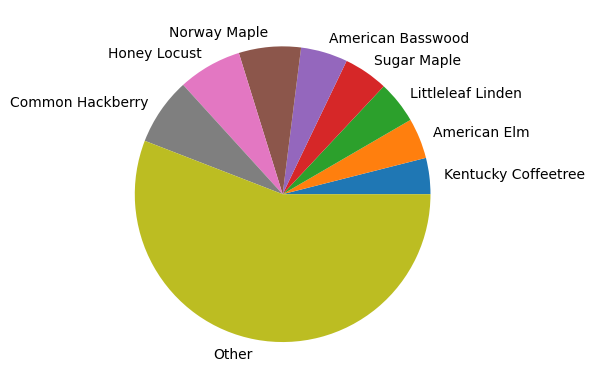

In [12]:
# What does the population of trees in Minneapolis look like by species?

# First, find the top 8 trees and rename the other trees
mpls_tree_counts = mpls_trees.value_counts("common_name")[:8]

mpls_trees_top_8 = mpls_trees.copy()
mpls_trees_top_8.loc[~mpls_trees_top_8["common_name"].isin(mpls_tree_counts.index), "common_name"] = "Other"

# Now count the trees belonging to the top 8 trees, and all of the others. Create a pie chart
mpls_tree_counts_top_8 = mpls_trees_top_8.value_counts("common_name").sort_values(ascending=True)
mpls_tree_counts_top_8.plot(kind="pie");

In [ ]:
mpls_trees